Question 7

In [10]:
from google.colab import files

print("Please upload the 'Q2_data.csv' file:")
files.upload()

Please upload the 'Q2_data.csv' file:


Saving A4_test_a4d66d34-6db0-44a4-a7c1-0aa26ab8d705.csv to A4_test_a4d66d34-6db0-44a4-a7c1-0aa26ab8d705 (1).csv
Saving A4_train_74e601c5-f446-4f34-a53b-28ce05d1cec4.csv to A4_train_74e601c5-f446-4f34-a53b-28ce05d1cec4 (1).csv


{'A4_test_a4d66d34-6db0-44a4-a7c1-0aa26ab8d705 (1).csv': b'Feature1,Feature2,Label\n0.9111000142690808,-0.4991374021868795,0.0\n-1.460325689773874,-0.6816420934612732,0.0\n-1.063949879418192,-1.106004403195248,0.0\n1.7230532243138474,1.1598358338889825,1.0\n-1.0787292611933288,1.067449751703554,0.0\n0.6676191700024967,0.7721797576906221,1.0\n0.24419983801884015,0.03151196953649149,0.0\n-1.4390765531598695,-0.7176011290023961,0.0\n-1.501023197515714,-0.7830127342225475,0.0\n0.7683675418961458,-1.3032878214774597,1.0\n-0.5141499827419371,0.6097920383598694,0.0\n0.8881295116917522,-1.1992559956237248,1.0\n1.4027390412899194,-0.2985666282467817,1.0\n-2.083319862654995,1.8700225279340779,0.0\n-1.9242891188080251,1.728889791023524,0.0\n0.6955867378646252,-1.7880173674232454,1.0\n-1.4045636792818605,-0.7640354965094489,0.0\n1.569446744907041,0.7403995043657934,1.0\n-1.4911683656473969,1.3904848948724973,0.0\n0.03928840771180275,1.210779939494541,1.0\n-0.5002941745827656,-1.3510131812274524,0.

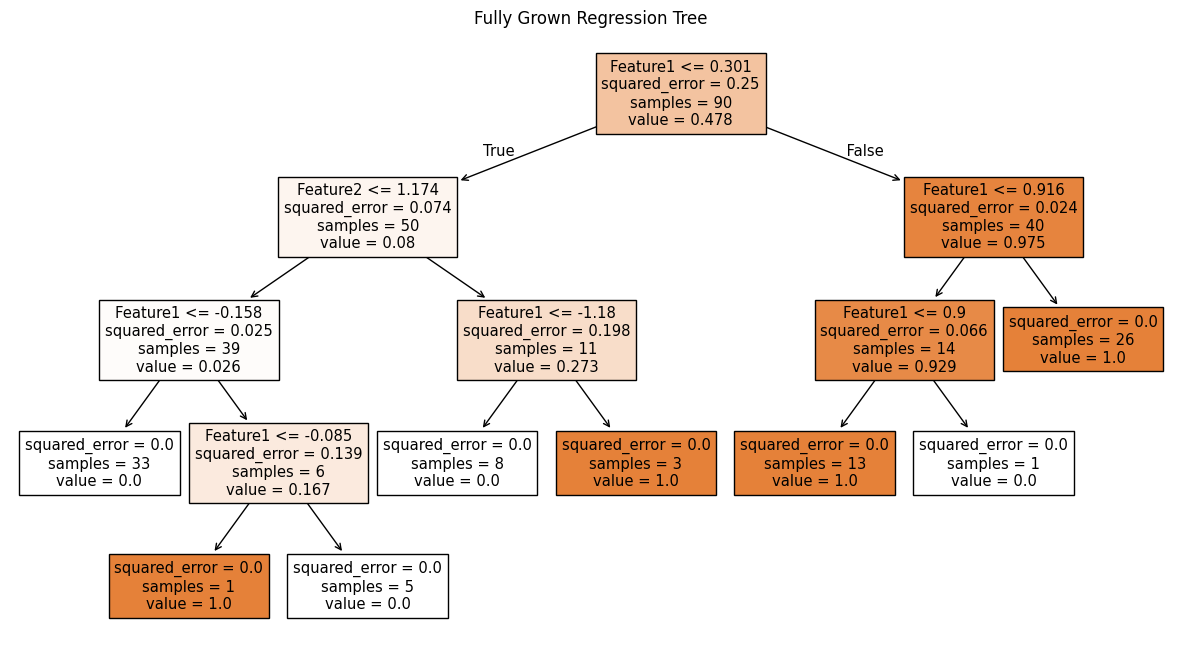

In [15]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
data = pd.read_csv("A4_test_a4d66d34-6db0-44a4-a7c1-0aa26ab8d705.csv")

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

reg_tree = DecisionTreeRegressor(random_state=42)
reg_tree.fit(X, y)

plt.figure(figsize=(15, 8))
plot_tree(reg_tree, feature_names=X.columns, filled=True)
plt.title("Fully Grown Regression Tree")
plt.show()

Queston 8

A.

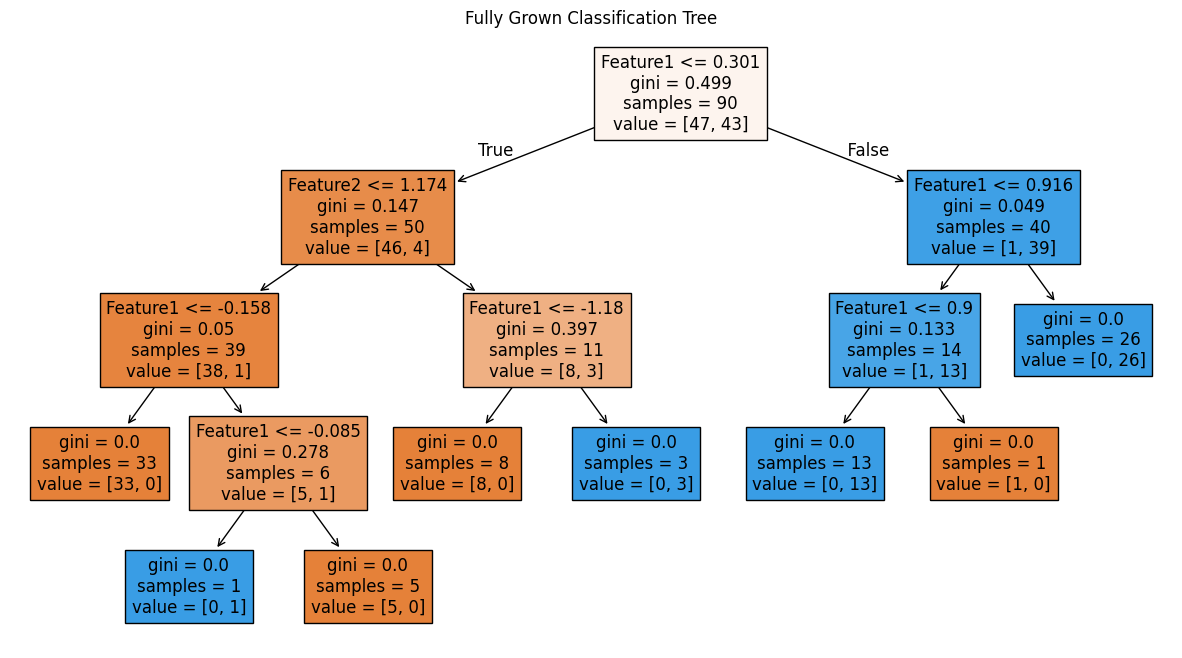

In [7]:
from sklearn.tree import DecisionTreeClassifier

train = pd.read_csv("A4_test_a4d66d34-6db0-44a4-a7c1-0aa26ab8d705.csv")

X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

clf = DecisionTreeClassifier(criterion="gini", random_state=42)
clf.fit(X_train, y_train)

plt.figure(figsize=(15, 8))
plot_tree(clf, feature_names=X_train.columns, filled=True)
plt.title("Fully Grown Classification Tree")
plt.show()

B.

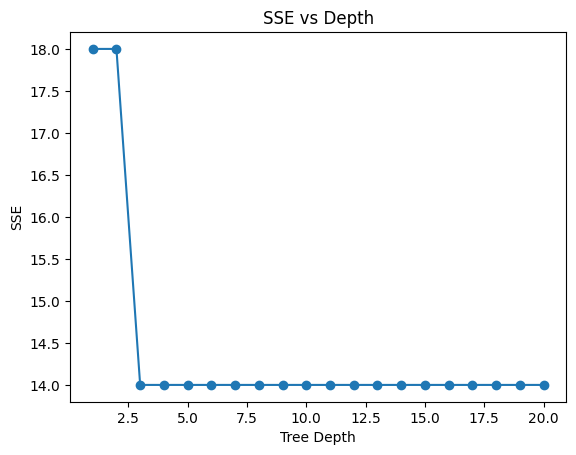

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

test = pd.read_csv("A4_train_74e601c5-f446-4f34-a53b-28ce05d1cec4 (1).csv")

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

depths = range(1, 21)
sse_list = []

for d in depths:
    model = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)


    sse = np.sum((y_test - y_pred) ** 2)
    sse_list.append(sse)

plt.figure()
plt.plot(depths, sse_list, marker='o')
plt.xlabel("Tree Depth")
plt.ylabel("SSE")
plt.title("SSE vs Depth")
plt.show()

C.

In [13]:
sse_diff = np.diff(sse_list)

optimal_index = np.argmin(np.abs(sse_diff))

optimal_depth = depths[optimal_index + 1]

print("Optimal Depth:", optimal_depth)

Optimal Depth: 2


D.

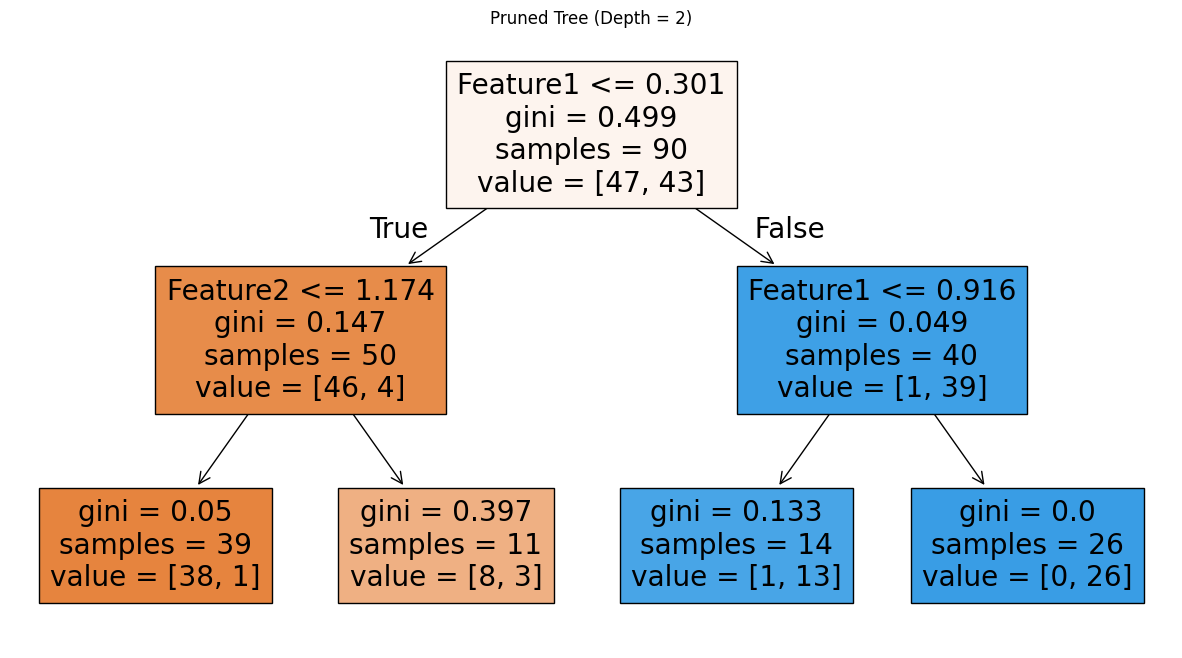

In [17]:
pruned_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=optimal_depth,
    random_state=42
)

pruned_model.fit(X_train, y_train)

plt.figure(figsize=(15, 8))
plot_tree(pruned_model, feature_names=X_train.columns, filled=True)
plt.title(f"Pruned Tree (Depth = {optimal_depth})")
plt.show()